In [5]:
BASELINE_CSV = "/content/carl_inference_result_1_baseline_summary.csv"
EXTENSION_CSV = "/content/carl_inference_result_1_extension_summary.csv"

# (optional) If you instead have ONE combined CSV, set COMBINED_CSV path and set USE_COMBINED=True
COMBINED_CSV = "/content/inference_summary.csv"   # optional
USE_COMBINED = False

# Known scenario sets (from your training split)
BASELINE_SCENARIOS = {
    'ControlLoss',
    'HardBreakRoute',
    'DynamicObjectCrossing',
    'VehicleTurningRoute',
    'SignalizedJunctionLeftTurn',
    'OppositeVehicleRunningRedLight',
    'SignalizedJunctionRightTurn'
}
EXTENSION_SCENARIOS = {
    'Accident',
    'AccidentTwoWays',
    'BlockedIntersection',
    'ConstructionObstacle',
    'ConstructionObstacleTwoWays'
}

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.grid"] = True

def load_data():
    if USE_COMBINED and os.path.exists(COMBINED_CSV):
        df = pd.read_csv(COMBINED_CSV)
        # infer group from scenario_type
        df["group"] = df["scenario_type"].apply(lambda s: "Baseline" if s in BASELINE_SCENARIOS
                                                else ("Extension" if s in EXTENSION_SCENARIOS else "Unknown"))
        return df
    else:
        df_b = pd.read_csv(BASELINE_CSV)
        df_b["group"] = "Baseline"
        df_e = pd.read_csv(EXTENSION_CSV)
        df_e["group"] = "Extension"
        return pd.concat([df_b, df_e], ignore_index=True)

def mean_sem(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return pd.Series({
        "mean": x.mean(),
        "sem": x.std(ddof=1) / math.sqrt(len(x)) if len(x)>1 else np.nan,
        "n": len(x)
    })

def savefig(name):
    plt.tight_layout()
    out = f"/content/{name}.png"
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved: {out}")

In [6]:
df = load_data()

# cleaning
for col in ["score_composed","score_penalty","score_route","duration_game","duration_system","num_infractions"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary completion flag
df["completed"] = df["status"].isin(["Completed","Perfect"]).astype(int)
# A simple rate: infractions per minute of game time (avoid div-by-zero)
if "num_infractions" in df.columns and "duration_game" in df.columns:
    df["infractions_per_min"] = df["num_infractions"] / np.clip(df["duration_game"]/60.0, 1e-6, None)
else:
    df["infractions_per_min"] = np.nan

## Summary Table

In [7]:
group_summary = df.groupby("group").agg(
    n=("score_composed","count"),
    score_mean=("score_composed","mean"),
    score_std=("score_composed","std"),
    completion_rate=("completed","mean"),
    infr_per_min=("infractions_per_min","mean")
).reset_index()
group_summary["completion_rate"] = group_summary["completion_rate"]*100

print("=== Group Summary ===")
print(group_summary.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

=== Group Summary ===
    group  n  score_mean  score_std  completion_rate  infr_per_min
 Baseline 13       64.25      20.51            92.31          4.87
Extension  7       34.49      13.75           100.00          1.64


## Scenario-level breakdown

In [8]:
scen_summary = df.groupby(["group","scenario_type"]).agg(
    n=("score_composed","count"),
    score_mean=("score_composed","mean"),
    score_sem=("score_composed", lambda s: s.std(ddof=1)/math.sqrt(len(s)) if len(s)>1 else np.nan),
    completion_rate=("completed","mean")
).reset_index()
scen_summary["completion_rate"] = scen_summary["completion_rate"]*100

print("\n=== Scenario Breakdown ===")
print(scen_summary.sort_values(["group","scenario_type"]).to_string(index=False, float_format=lambda v: f"{v:.2f}"))


=== Scenario Breakdown ===
    group                  scenario_type  n  score_mean  score_sem  completion_rate
 Baseline                    ControlLoss  3       86.57       7.64           100.00
 Baseline          DynamicObjectCrossing  2       49.82       0.13           100.00
 Baseline                 HardBreakRoute  4       56.29       4.74           100.00
 Baseline OppositeVehicleRunningRedLight  2       67.02      32.98            50.00
 Baseline    SignalizedJunctionRightTurn  2       58.34       1.66           100.00
Extension                       Accident  2       23.38       6.36           100.00
Extension                AccidentTwoWays  1       57.34        NaN           100.00
Extension            BlockedIntersection  1       48.78        NaN           100.00
Extension           ConstructionObstacle  3       29.53       1.09           100.00


## 1) Histogram: composed score distributions

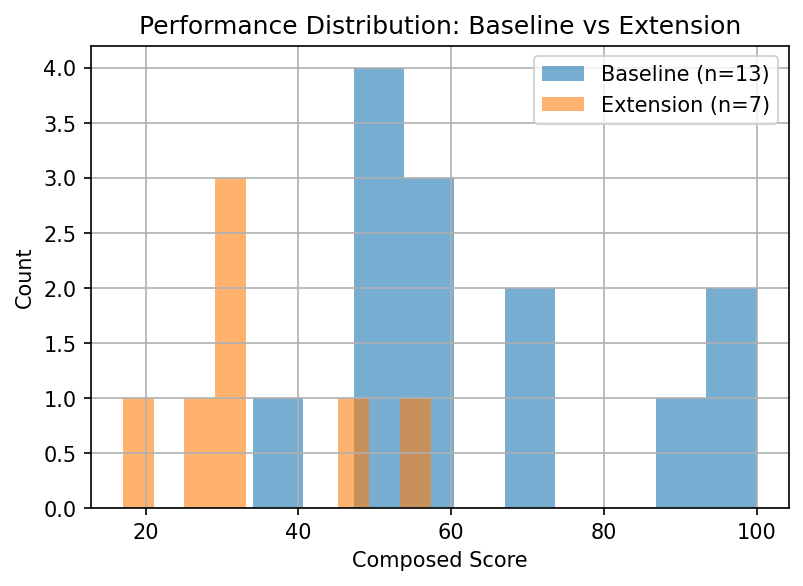

Saved: /content/hist_score_composed.png


<Figure size 960x720 with 0 Axes>

In [9]:
plt.figure(figsize=(6,4))
for g, color, alpha in [("Baseline", None, 0.6), ("Extension", None, 0.6)]:
    sub = df[df["group"]==g]["score_composed"].dropna()
    if len(sub)>0:
        plt.hist(sub, bins=10, alpha=alpha, label=f"{g} (n={len(sub)})")
plt.xlabel("Composed Score")
plt.ylabel("Count")
plt.title("Performance Distribution: Baseline vs Extension")
plt.legend()
plt.show()
savefig("hist_score_composed")

## 2) Boxplot: variance comparison

/tmp/ipython-input-2584495724.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=["Baseline","Extension"], showmeans=True)


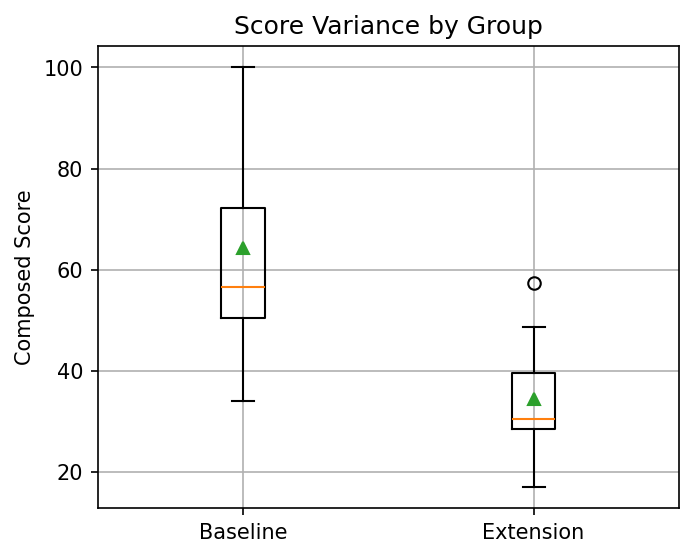

Saved: /content/box_score_composed.png


<Figure size 960x720 with 0 Axes>

In [10]:
plt.figure(figsize=(5,4))
box_data = [df[df["group"]=="Baseline"]["score_composed"].dropna(),
            df[df["group"]=="Extension"]["score_composed"].dropna()]
plt.boxplot(box_data, labels=["Baseline","Extension"], showmeans=True)
plt.ylabel("Composed Score")
plt.title("Score Variance by Group")
plt.show()
savefig("box_score_composed")

## 3) Bar (Mean ± SEM) by group

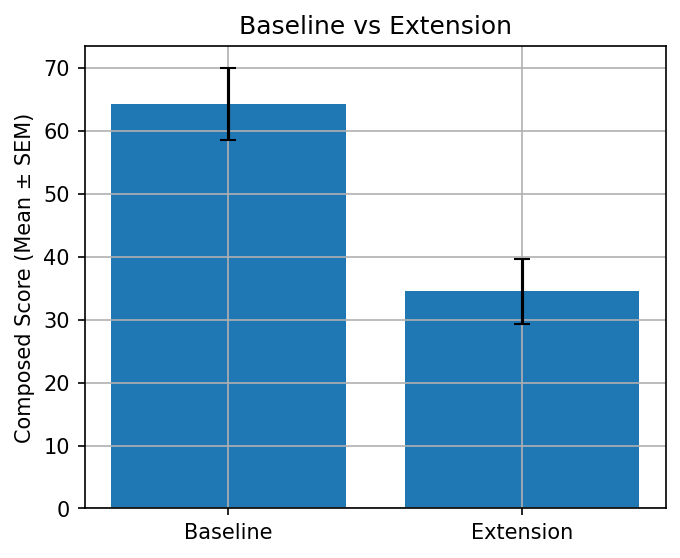

Saved: /content/bar_mean_sem_group.png


<Figure size 960x720 with 0 Axes>

In [11]:
plt.figure(figsize=(5,4))
means = group_summary["score_mean"].values
sems = df.groupby("group")["score_composed"].apply(lambda s: s.std(ddof=1)/math.sqrt(len(s)) if len(s)>1 else np.nan).values
xticks = group_summary["group"].tolist()
x = np.arange(len(xticks))
plt.bar(x, means, yerr=sems, capsize=4)
plt.xticks(x, xticks)
plt.ylabel("Composed Score (Mean ± SEM)")
plt.title("Baseline vs Extension")
plt.show()
savefig("bar_mean_sem_group")

## 4) Stacked bars: completion

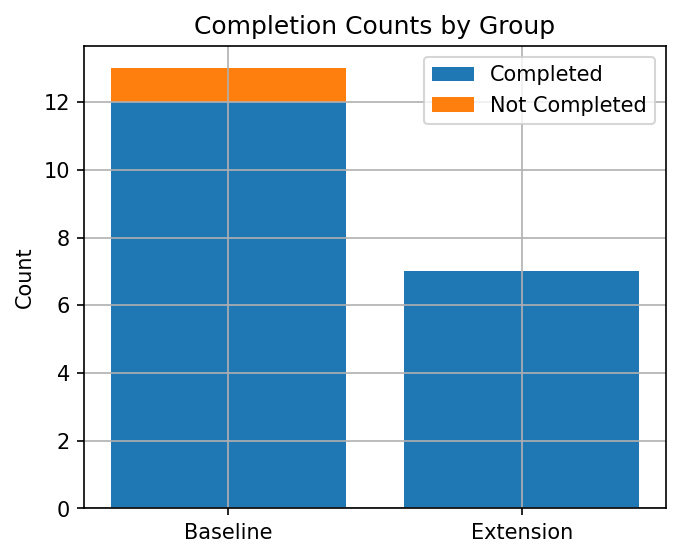

Saved: /content/stacked_completion.png


<Figure size 960x720 with 0 Axes>

In [12]:
comp = df.groupby("group")["completed"].agg(["sum","count"])
completed = comp["sum"].values
not_completed = (comp["count"] - comp["sum"]).values
labels = comp.index.tolist()
x = np.arange(len(labels))

plt.figure(figsize=(5,4))
plt.bar(x, completed, label="Completed")
plt.bar(x, not_completed, bottom=completed, label="Not Completed")
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Completion Counts by Group")
plt.legend()
plt.show()
savefig("stacked_completion")

## 5) Scenario type bars (mean ± SEM), grouped by Baseline/Extension

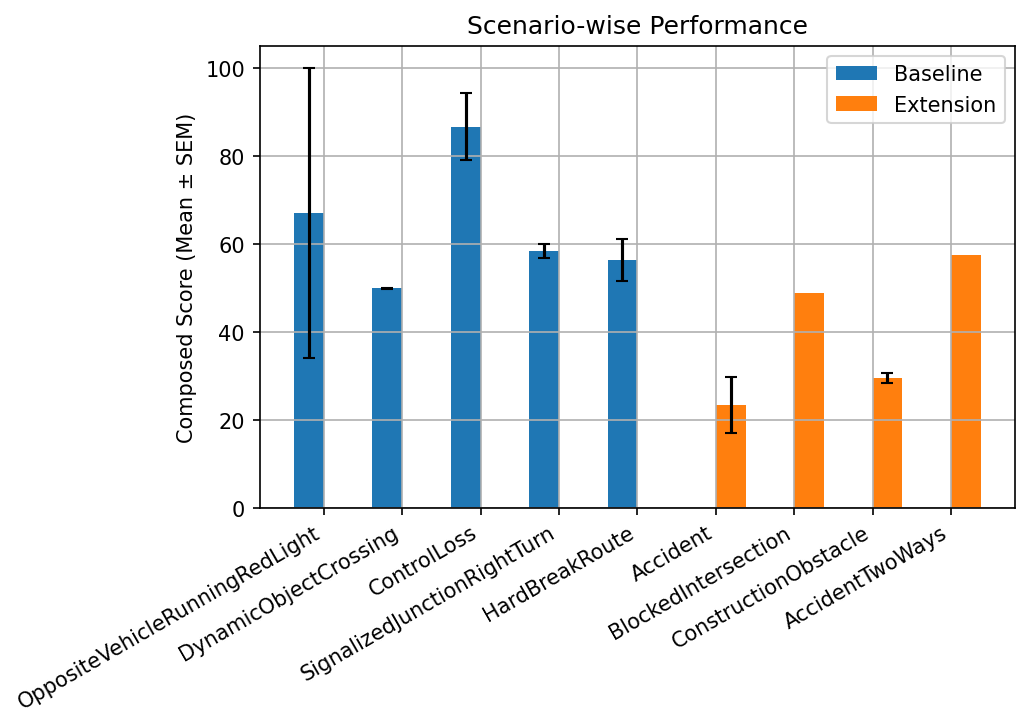

Saved: /content/bar_scenario_mean_sem.png


<Figure size 960x720 with 0 Axes>

In [14]:
# Keep scenario order stable: baseline scenarios first, then extension ones
order = list(BASELINE_SCENARIOS) + list(EXTENSION_SCENARIOS)

# ensure scenario_type & score_composed present
df_scen = df.dropna(subset=["scenario_type", "score_composed"]).copy()

# compute mean/std/count → sem
scen_stats = (
    df_scen.groupby(["scenario_type", "group"])["score_composed"]
           .agg(["mean", "std", "count"])
           .reset_index()
)
scen_stats["sem"] = scen_stats["std"] / np.sqrt(scen_stats["count"].clip(lower=1))

# enforce a readable order (only categories that actually appear)
present = [s for s in order if s in scen_stats["scenario_type"].unique()]
if not present:
    present = sorted(scen_stats["scenario_type"].unique().tolist())

# pivot to align bars
mean_p = scen_stats.pivot(index="scenario_type", columns="group", values="mean").reindex(present)
sem_p  = scen_stats.pivot(index="scenario_type", columns="group", values="sem").reindex(present)

groups = ["Baseline", "Extension"]
width = 0.38
x = np.arange(len(present))

plt.figure(figsize=(max(6, 0.5*len(present)+2), 4))
for i, g in enumerate(groups):
    means = mean_p[g].values if g in mean_p.columns else np.full(len(present), np.nan)
    sems  = sem_p[g].values  if g in sem_p.columns  else np.full(len(present), np.nan)
    plt.bar(x + (i-0.5)*width, means, width=width, yerr=sems, capsize=3, label=g)

plt.xticks(x, present, rotation=30, ha="right")
plt.ylabel("Composed Score (Mean ± SEM)")
plt.title("Scenario-wise Performance")
plt.legend()
plt.show()
savefig("bar_scenario_mean_sem")